# Bangalore Housing Price Prediction using Linear Regression

In this project, we will build a machine learning model to predict house prices in Bangalore using Linear Regression.

In [85]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error

## Importing Libraries and Loading Dataset

Import the required libraries and load the dataset into a Pandas DataFrame.

In [86]:
df = pd.read_csv('W:/Data-Science-Main/Data/bangalore.csv')

## Understanding Dataset Size

Check the number of rows and columns present in the dataset.

In [87]:
df.shape

(5860, 11)

## Dataset Information

Inspect column names, data types, and non-null counts.

In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5860 entries, 0 to 5859
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   location               5860 non-null   str    
 1   area_sqft              5860 non-null   int64  
 2   bedrooms               5860 non-null   int64  
 3   bathrooms              5860 non-null   int64  
 4   balconies              5860 non-null   int64  
 5   age_years              5860 non-null   int64  
 6   distance_to_it_hub_km  5860 non-null   float64
 7   nearest_metro_km       5274 non-null   float64
 8   parking_spaces         5860 non-null   int64  
 9   amenity_score          5860 non-null   float64
 10  price_lakh             5860 non-null   float64
dtypes: float64(4), int64(6), str(1)
memory usage: 503.7 KB


## Statistical Summary

Generate descriptive statistics for all numerical features.

In [89]:
df.describe()

,area_sqft,bedrooms,bathrooms,balconies,age_years,distance_to_it_hub_km,nearest_metro_km,parking_spaces,amenity_score,price_lakh
count,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5274.000000,5860.000000,5860.000000,5860.000000
mean,1391.044198,2.559386,2.647440,1.502389,14.739761,12.700082,6.187744,1.198635,70.114096,153.971927
std,826.375158,1.424575,1.515219,1.118890,8.646715,7.066020,3.424442,1.063506,17.209968,82.199292
min,400.000000,1.000000,1.000000,0.000000,0.000000,0.500000,0.200000,0.000000,40.000000,25.000000
25%,817.000000,1.000000,1.000000,0.000000,7.000000,6.657500,3.212500,0.000000,55.400000,95.987500
50%,1187.500000,2.000000,2.000000,2.000000,15.000000,12.785000,6.220000,1.000000,70.000000,136.735000
75%,1737.000000,3.000000,4.000000,2.000000,22.000000,18.860000,9.220000,2.000000,84.900000,192.272500
max,6000.000000,6.000000,7.000000,3.000000,29.000000,25.000000,12.000000,4.000000,100.000000,669.710000


## Missing Value Analysis

Identify missing values in each column.

In [90]:
df.isnull().sum()

location                   0
area_sqft                  0
bedrooms                   0
bathrooms                  0
balconies                  0
age_years                  0
distance_to_it_hub_km      0
nearest_metro_km         586
parking_spaces             0
amenity_score              0
price_lakh                 0
dtype: int64

## Feature Distribution Analysis

Visualize distributions of numerical variables using histograms.

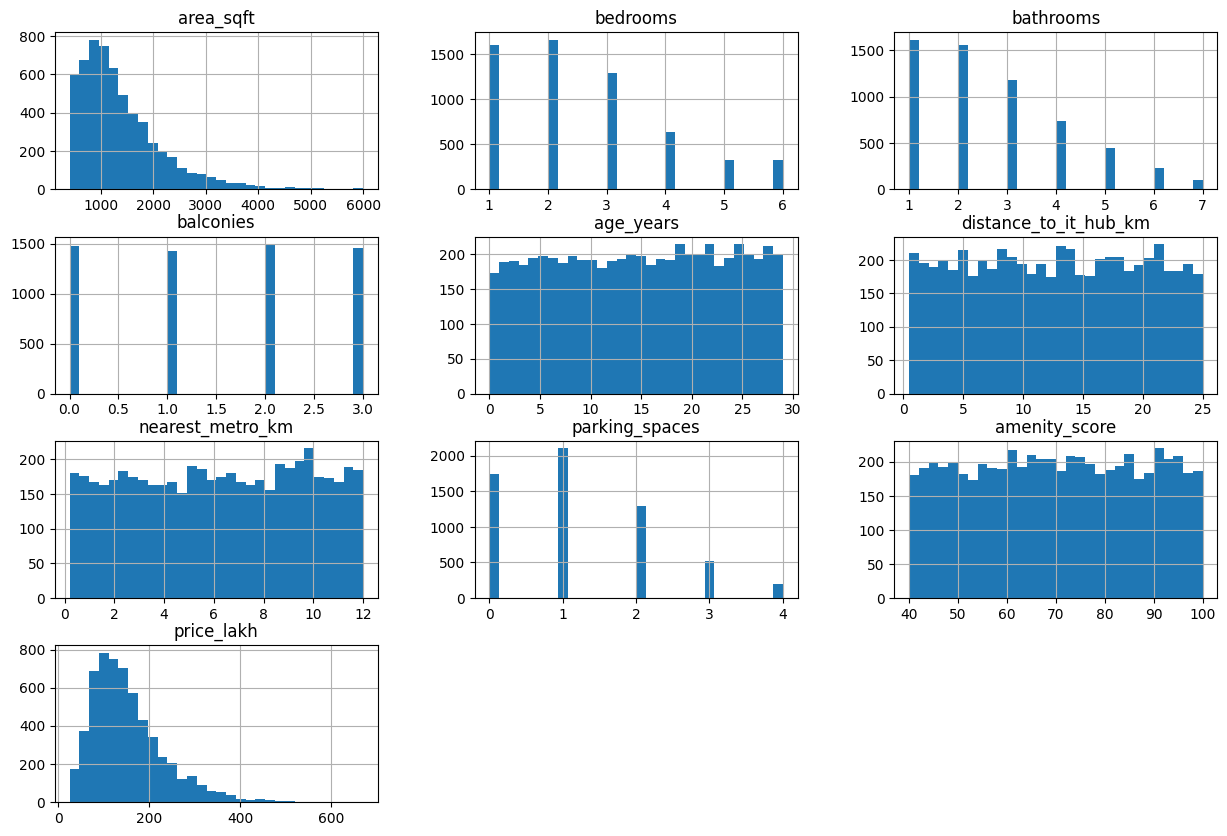

In [91]:
df.hist(figsize=(15,10), bins=30)
plt.show()

## Price Distribution Visualization

Analyze how house prices are distributed.

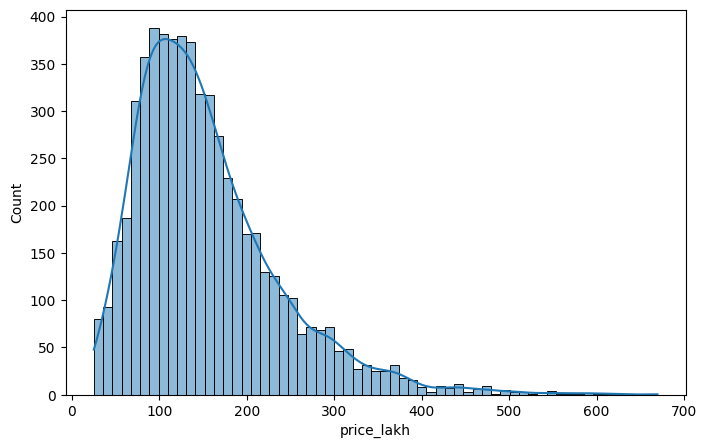

In [92]:
plt.figure(figsize=(8,5))
sns.histplot(df['price_lakh'], kde=True)
plt.show()

## Correlation Heatmap

Understand relationships between numerical features.

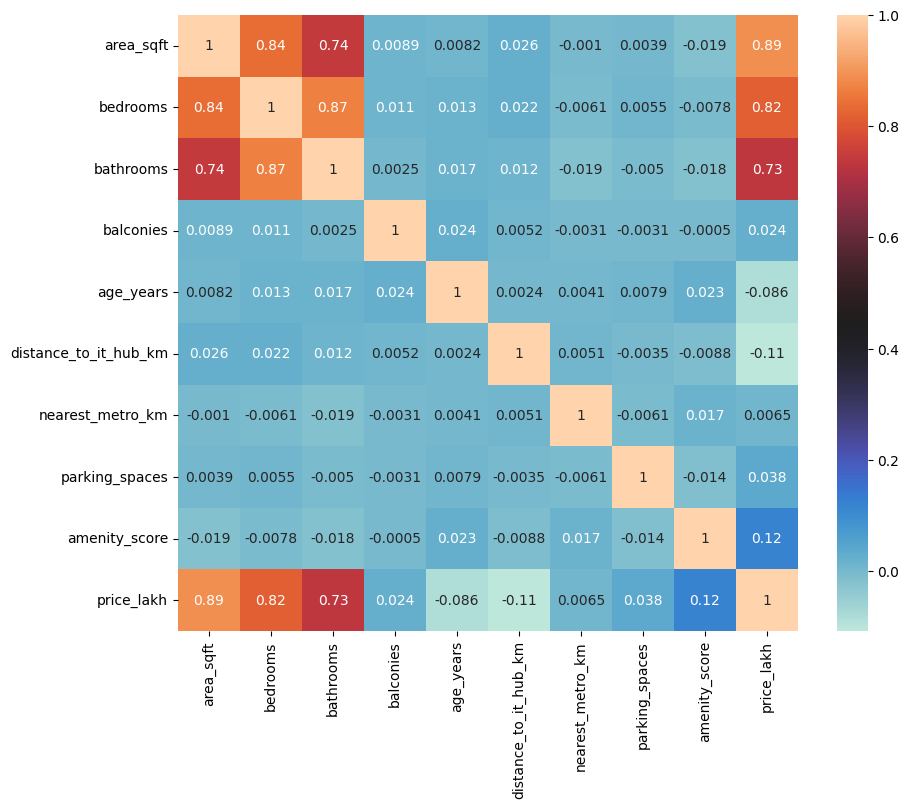

In [93]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='icefire')
plt.show()

## Feature vs Target Analysis

Visualize relationships between important features and house prices.

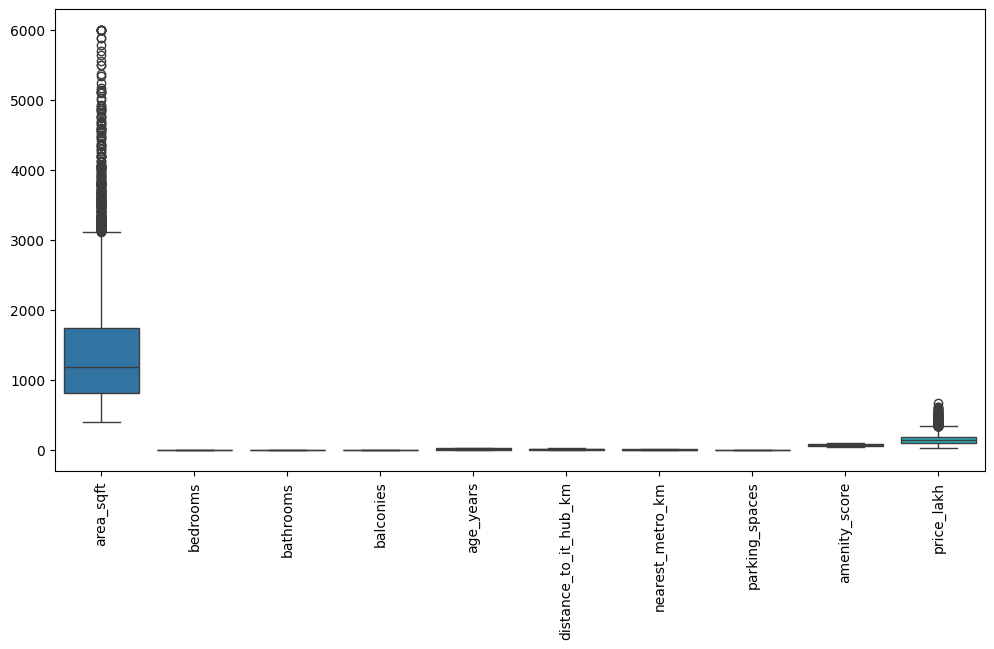

In [94]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.show()

## Outlier Detection

Calculate outlier counts and percentages using the IQR method.

In [95]:
outlier_summary = []

numericalCols = df.select_dtypes(include=np.number).columns

for col in numericalCols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    count = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ].shape[0]

    outlier_summary.append([col, count])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=['Feature', 'Outlier Count']
)

outlier_df

,Feature,Outlier Count
0,area_sqft,262
1,bedrooms,0
2,bathrooms,0
3,balconies,0
4,age_years,0
5,distance_to_it_hub_km,0
6,nearest_metro_km,0
7,parking_spaces,0
8,amenity_score,0
9,price_lakh,213


In [96]:
outlier_df['Outlier Percentage'] = (
    outlier_df['Outlier Count'] / len(df)
) * 100

outlier_df['Outlier Percentage'] = outlier_df['Outlier Percentage'].round(2).astype(str) + "%"

outlier_df

,Feature,Outlier Count,Outlier Percentage
0,area_sqft,262,4.47%
1,bedrooms,0,0.0%
2,bathrooms,0,0.0%
3,balconies,0,0.0%
4,age_years,0,0.0%
5,distance_to_it_hub_km,0,0.0%
6,nearest_metro_km,0,0.0%
7,parking_spaces,0,0.0%
8,amenity_score,0,0.0%
9,price_lakh,213,3.63%


## Rechecking Missing Values

Verify missing values before data cleaning.

In [97]:
df.isnull().sum()

location                   0
area_sqft                  0
bedrooms                   0
bathrooms                  0
balconies                  0
age_years                  0
distance_to_it_hub_km      0
nearest_metro_km         586
parking_spaces             0
amenity_score              0
price_lakh                 0
dtype: int64

## Exploring `nearest_metro_km`

Inspect the feature with missing values.

In [98]:
df['nearest_metro_km']

0         NaN
1        8.76
2        8.78
3        7.52
4        9.20
        ...  
5855     3.68
5856     9.05
5857    10.13
5858     1.65
5859     1.00
Name: nearest_metro_km, Length: 5860, dtype: float64

## Summary Statistics for `nearest_metro_km`

Analyze the distribution of metro distance values.

In [99]:
df['nearest_metro_km'].describe()

count    5274.000000
mean        6.187744
std         3.424442
min         0.200000
25%         3.212500
50%         6.220000
75%         9.220000
max        12.000000
Name: nearest_metro_km, dtype: float64

## Mean Value Calculation

Compute the mean for the feature.

In [100]:
df['nearest_metro_km'].mean()

np.float64(6.187743648084945)

## Median Value Calculation

Compute the median for the feature.

In [101]:
df['nearest_metro_km'].median()

np.float64(6.22)

## Handling Missing Values

Replace missing values using the median.

In [102]:
df['nearest_metro_km'] = df['nearest_metro_km'].fillna(df['nearest_metro_km'].median())

## Validation After Imputation

Ensure all missing values have been handled.

In [103]:
df.isna().sum()

location                 0
area_sqft                0
bedrooms                 0
bathrooms                0
balconies                0
age_years                0
distance_to_it_hub_km    0
nearest_metro_km         0
parking_spaces           0
amenity_score            0
price_lakh               0
dtype: int64

## Exploring Categorical Features

Review unique locations present in the dataset.

In [104]:
df['location'].unique()

<StringArray>
[    'Koramangala',      'HSR Layout',       'Jayanagar',     'Indiranagar',
    'Marathahalli',        'JP Nagar',   'Sarjapur Road',       'Bellandur',
 'Electronic City',          'Hebbal',      'Whitefield',       'Yelahanka']
Length: 12, dtype: str

## Encoding Categorical Variables

Convert location categories into numerical dummy variables.

In [105]:
df = pd.get_dummies(df, columns=['location'], drop_first=True)

## Dataset After Encoding

Preview the transformed dataset.

In [106]:
df

,area_sqft,bedrooms,bathrooms,balconies,age_years,distance_to_it_hub_km,nearest_metro_km,parking_spaces,amenity_score,price_lakh,location_Electronic City,location_HSR Layout,location_Hebbal,location_Indiranagar,location_JP Nagar,location_Jayanagar,location_Koramangala,location_Marathahalli,location_Sarjapur Road,location_Whitefield,location_Yelahanka
0,1795,3,4,0,24,14.53,6.22,3,53.6,189.68,False,False,False,False,False,False,True,False,False,False,False
1,1067,1,2,3,28,24.35,8.76,0,71.5,86.19,False,True,False,False,False,False,False,False,False,False,False
2,1720,3,3,0,22,2.46,8.78,1,95.4,240.91,False,False,False,False,False,True,False,False,False,False,False
3,925,2,1,1,5,11.78,7.52,3,77.9,174.00,False,False,False,True,False,False,False,False,False,False,False
4,4371,6,7,0,10,10.21,9.20,1,42.1,328.52,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5855,1704,3,4,3,26,12.84,3.68,1,74.3,138.01,False,False,False,False,False,False,False,True,False,False,False
5856,1402,3,4,0,28,5.92,9.05,0,93.0,158.02,False,False,False,False,False,False,False,False,False,False,False
5857,1044,3,4,0,2,9.76,10.13,2,94.3,234.65,False,False,False,True,False,False,False,False,False,False,False
5858,488,1,1,2,16,21.41,1.65,2,76.3,42.57,False,False,False,False,True,False,False,False,False,False,False


## Updated Dataset Shape

Check dimensions after feature engineering.

In [107]:
df.shape

(5860, 21)

## Feature and Target Separation

Split independent and dependent variables.

In [108]:
x = df.drop('price_lakh', axis=1)
y = df['price_lakh']

## Feature Summary

Review statistics of model input features.

In [109]:
x.describe()

,area_sqft,bedrooms,bathrooms,balconies,age_years,distance_to_it_hub_km,nearest_metro_km,parking_spaces,amenity_score
count,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000
mean,1391.044198,2.559386,2.647440,1.502389,14.739761,12.700082,6.190969,1.198635,70.114096
std,826.375158,1.424575,1.515219,1.118890,8.646715,7.066020,3.248695,1.063506,17.209968
min,400.000000,1.000000,1.000000,0.000000,0.000000,0.500000,0.200000,0.000000,40.000000
25%,817.000000,1.000000,1.000000,0.000000,7.000000,6.657500,3.540000,0.000000,55.400000
50%,1187.500000,2.000000,2.000000,2.000000,15.000000,12.785000,6.220000,1.000000,70.000000
75%,1737.000000,3.000000,4.000000,2.000000,22.000000,18.860000,8.902500,2.000000,84.900000
max,6000.000000,6.000000,7.000000,3.000000,29.000000,25.000000,12.000000,4.000000,100.000000


## Train-Test Split

Divide data into training and testing datasets.

In [110]:
xTrain, xTest, yTrain, yTest = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

## Training Data Inspection

Verify training feature distributions.

In [111]:
xTrain.describe()

,area_sqft,bedrooms,bathrooms,balconies,age_years,distance_to_it_hub_km,nearest_metro_km,parking_spaces,amenity_score
count,4688.000000,4688.000000,4688.000000,4688.000000,4688.000000,4688.000000,4688.000000,4688.000000,4688.000000
mean,1390.808660,2.555247,2.648251,1.506186,14.620734,12.674424,6.207528,1.200085,70.216916
std,819.659229,1.420362,1.515088,1.121375,8.665680,7.076155,3.262032,1.061811,17.226614
min,400.000000,1.000000,1.000000,0.000000,0.000000,0.500000,0.200000,0.000000,40.000000
25%,816.000000,1.000000,1.000000,0.000000,7.000000,6.597500,3.520000,0.000000,55.500000
50%,1189.500000,2.000000,2.000000,2.000000,15.000000,12.775000,6.220000,1.000000,70.100000
75%,1742.250000,3.000000,4.000000,3.000000,22.000000,18.860000,8.940000,2.000000,85.200000
max,6000.000000,6.000000,7.000000,3.000000,29.000000,25.000000,12.000000,4.000000,100.000000


## Initializing Linear Regression Model

Create the Linear Regression model object.

In [112]:
model = LinearRegression()

## Model Training

Train the model using the training data.

In [113]:
model.fit(xTrain,yTrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Making Predictions

Generate predictions on the test dataset.

In [114]:
prediction = model.predict(xTest)

## Model Evaluation

Calculate MSE, RMSE, and R² Score.

In [115]:
mse = mean_squared_error(yTest, prediction)

print("MSE :", mse)

rmse = root_mean_squared_error(yTest, prediction)

print("RMSE :", rmse)

r2 = (r2_score(yTest, prediction) * 100).__round__(2)

print("R² :", r2,"%")

MSE : 458.4123800221628
RMSE : 21.41056701776398
R² : 93.32 %


## Actual vs Predicted Prices

Visualize model predictions against actual values.

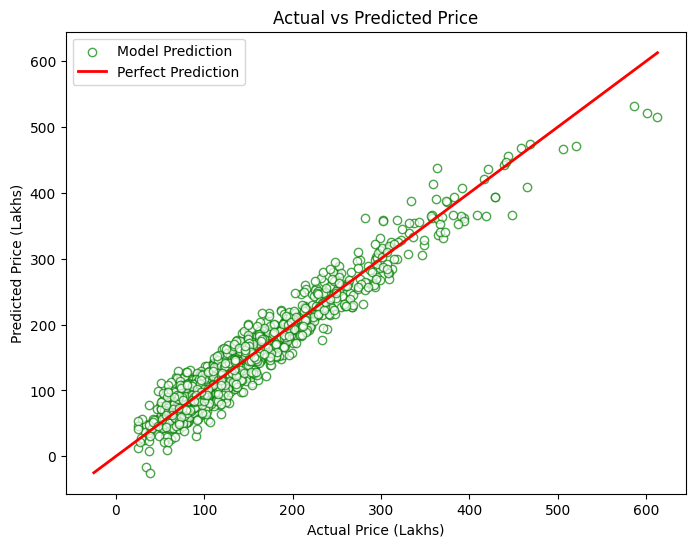

In [116]:
plt.figure(figsize=(8,6))

plt.scatter(
    yTest,
    prediction,
    alpha=0.7,
    color='white',
    edgecolors='green',
    label='Model Prediction'
)

min_val = min(yTest.min(), prediction.min())
max_val = max(yTest.max(), prediction.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='-',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.title("Actual vs Predicted Price")
plt.legend()

plt.show()

## Residual Analysis

Calculate residual errors.

In [117]:
residuals = yTest - prediction

## Residual Plot

Check for patterns in prediction errors.

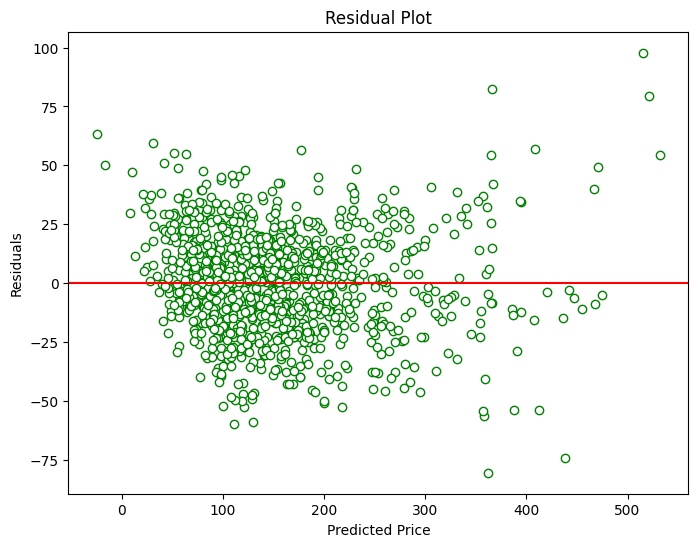

In [118]:
plt.figure(figsize=(8,6))

plt.scatter(prediction, residuals, alpha=1,color='white',
    edgecolors='green',
    label='Model Prediction')

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()